In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# ==========================================
# 1. Data Preparation (Mini-Batch Gradient Descent)
# ==========================================
transform = transforms.ToTensor()

# Download the full training dataset
full_train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Address Bias/Variance by creating a Validation Set
# We split the 60,000 training images into 50,000 for training and 10,000 for validation
train_size = 50000
val_size = 10000
train_data, val_data = random_split(full_train_data, [train_size, val_size])

# Mini-Batch Gradient Descent: We feed data in batches of 64
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# ==========================================
# 2. Model Architecture with Regularization
# ==========================================
class FashionNetReg(nn.Module):
    def __init__(self):
        super(FashionNetReg, self).__init__()
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        # REGULARIZATION: Dropout randomly turns off 30% of neurons to prevent overfitting
        self.dropout1 = nn.Dropout(0.3) 
        
        self.hidden2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        # REGULARIZATION: Dropout randomly turns off 30% of neurons
        self.dropout2 = nn.Dropout(0.2)
        
        self.output = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.hidden2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.output(x)
        return x

model = FashionNetReg()

# ==========================================
# 3. Setup, L2 Regularization, & Early Stopping
# ==========================================
criterion = nn.CrossEntropyLoss()

# REGULARIZATION: weight_decay=1e-4 applies L2 Regularization
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# EARLY STOPPING configurations
epochs = 50 # We set a high maximum epoch count
patience = 3 # Stop if validation loss doesn't improve for 3 epochs
best_val_loss = float('inf')
patience_counter = 0

# ==========================================
# 4. The Training Loop
# ==========================================
print("Starting training with Early Stopping...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train() 
    running_train_loss = 0.0
    
    for images, labels in train_loader:
        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
        
    avg_train_loss = running_train_loss / len(train_loader)
    
    # --- VALIDATION PHASE ---
    model.eval() # Turns off dropout!
    running_val_loss = 0.0
    
    with torch.no_grad():
        for images, labels in val_loader:
            predictions = model(images)
            loss = criterion(predictions, labels)
            running_val_loss += loss.item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # --- EARLY STOPPING LOGIC ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0 # Reset patience
        # Save the best model weights
        torch.save(model.state_dict(), 'best_fashion_model.pth')
    else:
        patience_counter += 1
        print(f"   -> No improvement in Val Loss. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("   -> Early Stopping Triggered! Restoring best weights...")
            # Load the best weights back into the model
            model.load_state_dict(torch.load('best_fashion_model.pth'))
            break

# ==========================================
# 5. Evaluation & Classification Report
# ==========================================
print("\nEvaluating the best model on unseen Test Data...")
model.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted_classes = torch.max(outputs, 1)
        
        # Save predictions and true labels to numpy arrays for Scikit-Learn
        all_predictions.extend(predicted_classes.numpy())
        all_true_labels.extend(labels.numpy())

# Calculate overall accuracy
acc = accuracy_score(all_true_labels, all_predictions)
print(f"\nOverall Test Accuracy: {acc * 100:.2f}%\n")

# Generate the detailed classification report
print("Classification Report:")
print(classification_report(all_true_labels, all_predictions, target_names=classes))

Starting training with Early Stopping...
Epoch [1/50] | Train Loss: 0.6001 | Val Loss: 0.4421
Epoch [2/50] | Train Loss: 0.4309 | Val Loss: 0.4028
Epoch [3/50] | Train Loss: 0.4000 | Val Loss: 0.3509
Epoch [4/50] | Train Loss: 0.3778 | Val Loss: 0.3417
Epoch [5/50] | Train Loss: 0.3662 | Val Loss: 0.3443
   -> No improvement in Val Loss. Patience: 1/3
Epoch [6/50] | Train Loss: 0.3517 | Val Loss: 0.3244
Epoch [7/50] | Train Loss: 0.3434 | Val Loss: 0.3375
   -> No improvement in Val Loss. Patience: 1/3
Epoch [8/50] | Train Loss: 0.3342 | Val Loss: 0.3168
Epoch [9/50] | Train Loss: 0.3286 | Val Loss: 0.3154
Epoch [10/50] | Train Loss: 0.3231 | Val Loss: 0.3202
   -> No improvement in Val Loss. Patience: 1/3
Epoch [11/50] | Train Loss: 0.3158 | Val Loss: 0.3137
Epoch [12/50] | Train Loss: 0.3126 | Val Loss: 0.3129
Epoch [13/50] | Train Loss: 0.3055 | Val Loss: 0.3166
   -> No improvement in Val Loss. Patience: 1/3
Epoch [14/50] | Train Loss: 0.3027 | Val Loss: 0.2969
Epoch [15/50] | Trai

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# ==========================================
# 1. Data Preparation (Mini-Batch & Val Split)
# ==========================================
# Load the dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# Class names for the classification report later
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# ==========================================
# 2. Model Architecture with Regularization
# ==========================================
model = Sequential([
    Flatten(input_shape=(28, 28)),
    
    # Hidden Layer 1: 256 neurons, ReLU, L2 Regularization (Weight Decay)
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    # REGULARIZATION: Dropout turns off 30% of neurons
    Dropout(0.3),
    
    # Hidden Layer 2: 128 neurons, ReLU, L2 Regularization
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    
    # Output Layer: 10 classes, Softmax for probabilities
    Dense(10, activation='softmax')
])

# ==========================================
# 3. Setup Optimizer and Loss
# ==========================================
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 4. Early Stopping Callback
# ==========================================
# Instead of manual tracking, Keras uses a Callback to monitor validation loss.
# restore_best_weights=True automatically reverts the model to its best state.
early_stop = EarlyStopping(monitor='val_loss', 
                           patience=3, 
                           restore_best_weights=True,
                           verbose=1)

# ==========================================
# 5. The Training Loop
# ==========================================
print("Starting training with Early Stopping...")

# validation_split=0.166 takes ~10,000 images out of the 60,000 for validation
# batch_size=64 applies our Mini-Batch Gradient Descent
history = model.fit(x_train_full, y_train_full, 
                    epochs=50, 
                    batch_size=64, 
                    validation_split=0.166, 
                    callbacks=[early_stop])

# ==========================================
# 6. Evaluation & Classification Report
# ==========================================
print("\nEvaluating the best model on unseen Test Data...")

# Get raw probability predictions for the test set
predictions_probs = model.predict(x_test)

# Convert probabilities to actual class predictions (e.g., [0.1, 0.8, 0.1] -> Class 1)
predicted_classes = np.argmax(predictions_probs, axis=1)

# Calculate overall accuracy
acc = accuracy_score(y_test, predicted_classes)
print(f"\nOverall Test Accuracy: {acc * 100:.2f}%\n")

# Generate the detailed classification report
print("Classification Report:")
print(classification_report(y_test, predicted_classes, target_names=classes))


🇬🇧 Classwork: CIFAR-10 Color Image Classification
Objective: Build a deep neural network to classify 32x32 color (RGB) images into 10 different categories using Mini-Batch Gradient Descent, Dropout, and Early Stopping.

Requirements:

Data Preparation: Load the cifar10 dataset from Keras. Scale the pixel values so they range between 0 and 1.

Model Architecture:

Add a Flatten layer. (Careful: the input shape is now (32, 32, 3)).

Create three hidden layers using Dense with the ReLU activation function. The sizes should be 512, 256, and 128 neurons, respectively.

Output layer must have 10 neurons with a softmax activation.

Regularization: Add a Dropout layer with a 20% drop rate (0.2) immediately after each of the three hidden layers to prevent overfitting.

Compilation: Use the adam optimizer and sparse_categorical_crossentropy for the loss function.

Training (Mini-Batch & Early Stopping):

Configure Early Stopping to monitor val_loss with a patience of 5 epochs. Ensure it restores the best weights.

Train the model for a maximum of 50 epochs.

Use a batch size of 128.

Set aside 20% of the training data for validation (validation_split=0.2).

Evaluation: Print the overall test accuracy and generate a classification report using Scikit-Learn.

🇦🇲 Դասարանային աշխատանք. CIFAR-10 Գունավոր պատկերների դասակարգում
Նպատակը՝ Կառուցել խորը նեյրոնային ցանց՝ 32x32 չափի գունավոր (RGB) պատկերները 10 տարբեր դասերի բաժանելու համար՝ կիրառելով մինի-փաթեթներով գրադիենտային վայրէջք (Mini-Batch Gradient Descent), Dropout ռեգուլյարիզացիա և վաղաժամ կանգառ (Early Stopping):

Պահանջները՝

Տվյալների նախապատրաստում: Ներբեռնեք cifar10 տվյալների բազան Keras-ից: Նորմալացրեք փիքսելների արժեքները այնպես, որ դրանք գտնվեն 0-ից 1 միջակայքում:

Մոդելի ճարտարապետություն:

Ավելացրեք Flatten շերտ: (Ուշադրություն՝ մուտքային տվյալների չափն այժմ (32, 32, 3) է):

Ստեղծեք երեք թաքնված շերտ (Dense)՝ ReLU ակտիվացման ֆունկցիայով: Նեյրոնների քանակը պետք է լինի համապատասխանաբար 512, 256 և 128:

Ելքային (Output) շերտը պետք է ունենա 10 նեյրոն՝ softmax ակտիվացմամբ:

Ռեգուլյարիզացիա: Յուրաքանչյուր թաքնված շերտից անմիջապես հետո ավելացրեք Dropout շերտ՝ 20% ինդեքսով (0.2), գերսովորումից (overfitting) խուսափելու համար:

Կոմպիլյացիա: Որպես օպտիմիզատոր օգտագործեք adam-ը, իսկ կորստի ֆունկցիայի համար՝ sparse_categorical_crossentropy:

Ուսուցում (Mini-Batch և Early Stopping):

Կարգավորեք վաղաժամ կանգառը (Early Stopping), որպեսզի այն հետևի val_loss-ին՝ 5 էպոխա համբերությամբ (patience=5): Համոզվեք, որ այն վերականգնում է լավագույն կշիռները:

Ուսուցանեք մոդելը առավելագույնը 50 էպոխա տևողությամբ:

Օգտագործեք 128 չափով մինի-փաթեթ (batch size = 128):

Ուսուցման տվյալների 20%-ը առանձնացրեք որպես վալիդացիայի բազմություն (validation_split=0.2):

Գնահատում: Տպեք թեստային տվյալների վերջնական ճշտությունը (accuracy) և գեներացրեք դասակարգման հաշվետվություն (classification report)՝ օգտագործելով Scikit-Learn գրադարանը:

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# 1. Data Preparation
print("Downloading CIFAR-10 dataset...")
cifar10 = tf.keras.datasets.cifar10
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# CIFAR-10 class names
classes = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 
           'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# # Scale the data (0 to 1)
# x_train_full = x_train_full / 255.0
# x_test = x_test / 255.0

# y_train comes as a 2D array (e.g., [[6], [9], ...]). Flatten it to 1D for sklearn later.
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# 2 & 3. Model Architecture & Regularization
model = Sequential([
    # Input shape is 32x32 pixels with 3 color channels (Red, Green, Blue)
    Flatten(input_shape=(32, 32, 3)),
    
    # Layer 1
    Dense(512, activation='relu'),
    Dropout(0.2),
    
    # Layer 2
    Dense(256, activation='relu'),
    Dropout(0.2),
    
    # Layer 3
    Dense(128, activation='relu'),
    Dropout(0.2),


    # Layer 4
    Dense(64, activation='relu'),
    Dropout(0.2),
    
    # Layer 5
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    # Output Layer
    Dense(10, activation='softmax')
])

# 4. Compilation
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Training Setup (Early Stopping & Mini-Batch)
early_stop = EarlyStopping(monitor='val_loss', 
                           patience=5, 
                           restore_best_weights=True,
                           verbose=0)

print("Starting training...")
history = model.fit(x_train_full, y_train_full, 
                    epochs=50, 
                    batch_size=128, # Mini-batch
                    validation_split=0.2, # 20% for validation
                    callbacks=[early_stop])

# 6. Evaluation
print("\nEvaluating the model on unseen Test Data...")
predictions_probs= model.predict(x_test)
predicted_classes = np.argmax(predictions_probs, axis=1)

# Overall Accuracy
acc = accuracy_score(y_test, predicted_classes)
print(f"\nOverall Test Accuracy: {acc * 100:.2f}%\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, predicted_classes, target_names=classes))

/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Starting training...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1043 - loss: 8.6898 - val_accuracy: 0.0999 - val_loss: 3.4219
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1014 - loss: 2.3093 - val_accuracy: 0.0987 - val_loss: 2.3028
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1007 - loss: 2.3030 - val_accuracy: 0.0985 - val_loss: 2.3026
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.1012 - loss: 2.3024 - val_accuracy: 0.0992 - val_loss: 2.3026
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.1006 - loss: 2.3030 - val_accuracy: 0.0954 - val_loss: 2.3026
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1011 - loss: 2.3027 - val_accuracy: 0.0980 - val_loss: 2.3027
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0966 - loss: 2.3028 - val_accuracy: 0.0951 - val_loss: 2.3027
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0996 - lo

/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [10]:
predictions_probs[0]

array([0.02737258, 0.01358667, 0.0920765 , 0.3210032 , 0.12669107,
       0.25337896, 0.07113809, 0.0308886 , 0.04768556, 0.01617877],
      dtype=float32)

Training samples: 45000, Validation: 5000, Test: 10000


/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "LeNet5_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,006 (242.21 KB)

 Trainable params: 62,006 (242.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3511 - loss: 1.8311 - val_accuracy: 0.3824 - val_loss: 1.7325
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4194 - loss: 1.6459 - val_accuracy: 0.4576 - val_loss: 1.5317
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4710 - loss: 1.5005 - val_accuracy: 0.4802 - val_loss: 1.4767
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4982 - loss: 1.4153 - val_accuracy: 0.5042 - val_loss: 1.3986
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5203 - loss: 1.3509 - val_accuracy: 0.5210 - val_loss: 1.3579
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5400 - loss: 1.2922 - val_accuracy: 0.5268 - val_loss: 1.3261
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5585 - loss: 1.2415 - val_accuracy: 0.5400 - val_loss: 1.3119
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5738 - loss: 1.2015 - val_accuracy: 0.

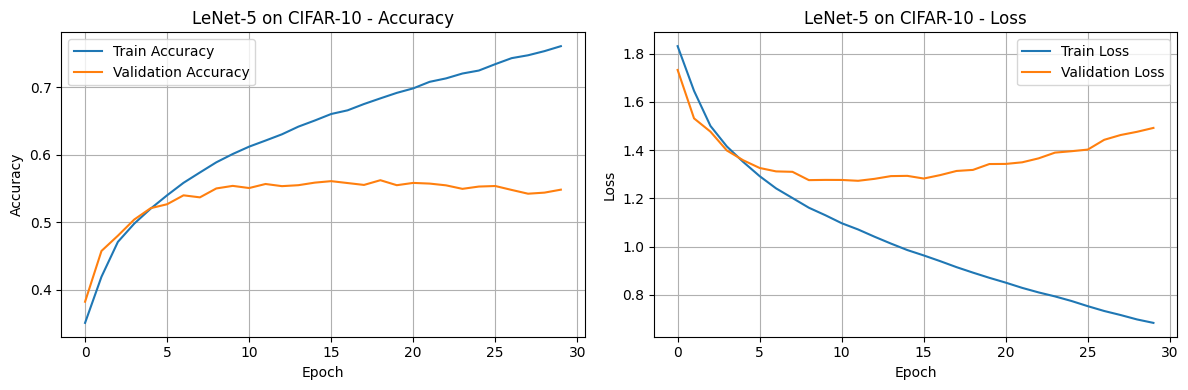

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


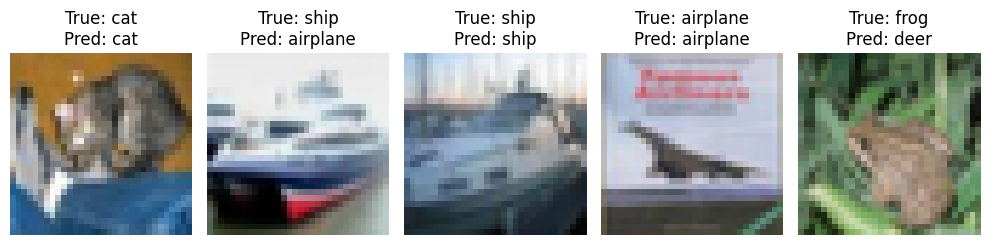

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------
# Load and preprocess CIFAR-10 dataset
# -------------------------------------------------------------------
# CIFAR-10: 60,000 32x32 color images in 10 classes (airplane, automobile, bird, cat, ...)
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to [0,1] for better training stability
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Convert labels to one-hot encoding for categorical crossentropy loss
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test  = keras.utils.to_categorical(y_test, num_classes=10)

# Optional: create validation split (e.g., 10% of training data)
val_split = 0.1
num_val_samples = int(x_train.shape[0] * val_split)
x_val = x_train[:num_val_samples]
y_val = y_train[:num_val_samples]
x_train = x_train[num_val_samples:]
y_train = y_train[num_val_samples:]

print(f"Training samples: {x_train.shape[0]}, Validation: {x_val.shape[0]}, Test: {x_test.shape[0]}")

# -------------------------------------------------------------------
# Build LeNet-5 architecture (adapted for CIFAR-10)
#
# Original LeNet-5 (LeCun et al., 1998) layers:
# - Input: 32x32 grayscale (for CIFAR-10 we use 3 channels)
# - C1: Conv 6@28x28 (5x5 kernel)
# - S2: Avg Pooling 6@14x14 (2x2)
# - C3: Conv 16@10x10 (5x5 kernel)
# - S4: Avg Pooling 16@5x5 (2x2)
# - C5: Conv 120@1x1 (5x5 kernel, originally fully connected)
# - F6: Dense 84
# - Output: Dense 10 (softmax)
#
# Modifications for CIFAR-10:
#   - Input shape: (32,32,3) instead of (32,32,1)
#   - First conv: 6 filters, 5x5, stride 1, padding 'valid' -> output 28x28
#   - Average pooling (2x2) -> 14x14
#   - Second conv: 16 filters, 5x5, valid -> 10x10
#   - Average pooling (2x2) -> 5x5
#   - Third conv: 120 filters, 5x5, valid -> 1x1 (since 5x5 input becomes 1x1)
#   - Flatten then Dense 84, then Dense 10
# -------------------------------------------------------------------
def LeNet5(input_shape=(32,32,3), num_classes=10):
    model = keras.Sequential(name="LeNet5_CIFAR10")

    # C1: Convolutional layer with 6 filters, 5x5 kernel, valid padding
    # Input: 32x32x3 -> Output: 28x28x6
    model.add(layers.Conv2D(6, kernel_size=(5,5), strides=(1,1),
                            activation='tanh', padding='valid',
                            input_shape=input_shape))
    # S2: Average pooling (2x2) -> 14x14x6
    model.add(layers.AveragePooling2D(pool_size=(2,2), strides=(2,2)))

    # C3: Second convolutional layer, 16 filters, 5x5, valid padding
    # Input: 14x14x6 -> Output: 10x10x16
    model.add(layers.Conv2D(16, kernel_size=(5,5), strides=(1,1),
                            activation='tanh', padding='valid'))
    # S4: Average pooling (2x2) -> 5x5x16
    model.add(layers.AveragePooling2D(pool_size=(2,2), strides=(2,2)))

    # C5: Convolutional layer with 120 filters, 5x5, valid padding
    # Input: 5x5x16 -> Output: 1x1x120 (since 5-5+1=1)
    model.add(layers.Conv2D(120, kernel_size=(5,5), strides=(1,1),
                            activation='tanh', padding='valid'))

    # Flatten the 1x1x120 feature maps into a 120-dimensional vector
    model.add(layers.Flatten())

    # F6: Fully connected layer with 84 units
    model.add(layers.Dense(84, activation='tanh'))

    # Output layer: 10 classes with softmax
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Instantiate the model
model = LeNet5(input_shape=(32,32,3), num_classes=10)

# Display model architecture
model.summary()

# -------------------------------------------------------------------
# Compile the model
# -------------------------------------------------------------------
# Use Adam optimizer (works well in practice) and categorical crossentropy
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# -------------------------------------------------------------------
# Train the model
# -------------------------------------------------------------------
batch_size = 64
epochs = 30  # LeNet-5 may need more epochs on CIFAR-10 due to higher complexity

# Using validation data for monitoring
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_val, y_val),
                    verbose=1)

# -------------------------------------------------------------------
# Evaluate on test set
# -------------------------------------------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# -------------------------------------------------------------------
# Plot training history
# -------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LeNet-5 on CIFAR-10 - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LeNet-5 on CIFAR-10 - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Example predictions (optional)
# -------------------------------------------------------------------
# Display first 5 test images with predictions
num_examples = 5
predictions = model.predict(x_test[:num_examples])
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test[:num_examples], axis=1)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 4))
for i in range(num_examples):
    plt.subplot(1, num_examples, i+1)
    plt.imshow(x_test[i])
    plt.title(f"True: {class_names[true_classes[i]]}\nPred: {class_names[predicted_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Training: 45000, Validation: 5000, Test: 10000


/Users/rafael/projects/ml_bootcamp/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "5Layer_CNN_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 552,714 (2.11 MB)

 Trainable params: 552,714 (2.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.4654 - loss: 1.4741 - val_accuracy: 0.5918 - val_loss: 1.1562
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6180 - loss: 1.0865 - val_accuracy: 0.6474 - val_loss: 1.0043
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6711 - loss: 0.9337 - val_accuracy: 0.6674 - val_loss: 0.9448
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7120 - loss: 0.8226 - val_accuracy: 0.6848 - val_loss: 0.9131
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7378 - loss: 0.7430 - val_accuracy: 0.6892 - val_loss: 0.9337
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7642 - loss: 0.6676 - val_accuracy: 0.6978 - val_loss: 0.8711
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7911 - loss: 0.5965 - val_accuracy: 0.7182 - val_loss: 0.8388
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8106 - loss: 0.5326 - 

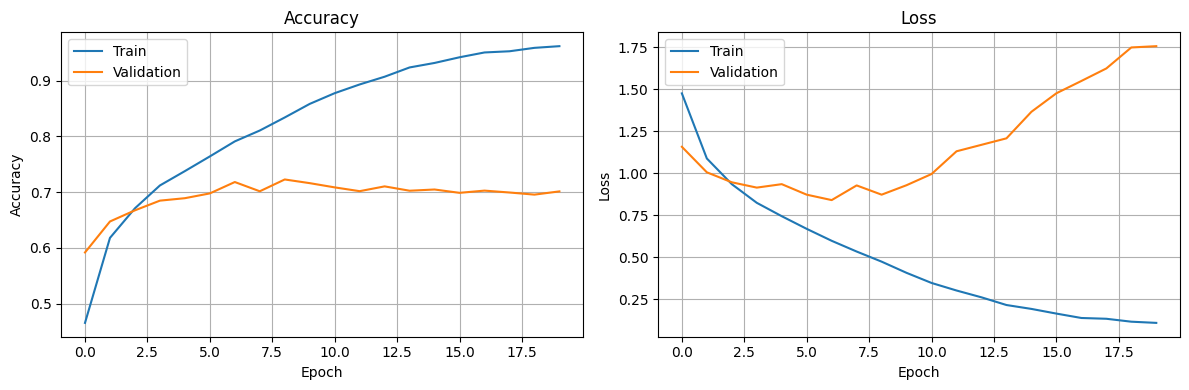

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


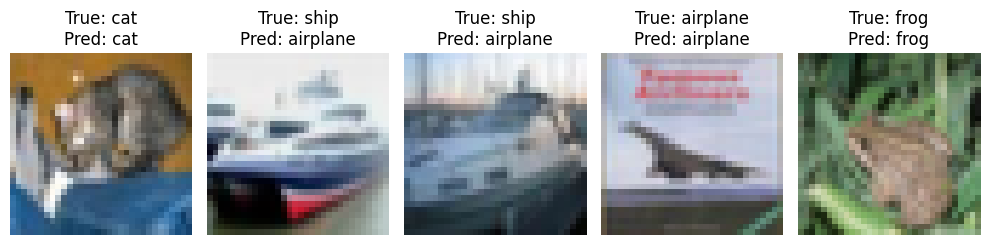

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------
# Load and preprocess CIFAR-10 dataset
# -------------------------------------------------------------------
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Convert labels to one-hot encoding (10 classes)
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test  = keras.utils.to_categorical(y_test, num_classes=10)

# Create a validation split (10% of training data)
val_split = 0.1
num_val_samples = int(x_train.shape[0] * val_split)
x_val = x_train[:num_val_samples]
y_val = y_train[:num_val_samples]
x_train = x_train[num_val_samples:]
y_train = y_train[num_val_samples:]

print(f"Training: {x_train.shape[0]}, Validation: {x_val.shape[0]}, Test: {x_test.shape[0]}")

# -------------------------------------------------------------------
# Build the model with exactly:
#   - 2 Conv2D layers (ReLU + MaxPooling each)
#   - 2 Dense layers (one hidden, one output)
# Total trainable layers = 2 (conv) + 2 (dense) = 4 layers?
# User asked for "5 layers" - we'll add an extra Dense to make it 5.
# But typical interpretation: Conv2D (1), MaxPool (not trainable), Conv2D (2), 
# MaxPool, Flatten, Dense (3), Dense (4), Output Dense (5). That's 5 trainable layers.
# Let's build: Conv2D+ReLU+MaxPool, Conv2D+ReLU+MaxPool, Flatten, Dense(128)+ReLU, Dense(10)+softmax.
# That gives 2 conv + 2 dense = 4 trainable? Actually Dense(128) and Dense(10) are two separate trainable layers.
# So total trainable = 2 + 2 = 4. To reach 5, we can add one more Dense layer (e.g., Dense(64)).
# We'll do: Conv2D(32) -> MaxPool -> Conv2D(64) -> MaxPool -> Flatten -> Dense(128) -> Dense(64) -> Dense(10).
# That's 2 conv + 3 dense = 5 trainable layers. Perfect.
# -------------------------------------------------------------------
model = keras.Sequential(name="5Layer_CNN_CIFAR10")

# First convolutional layer: 32 filters, 3x3 kernel, ReLU, same padding
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))                     # reduces size to 16x16

# Second convolutional layer: 64 filters, 3x3, ReLU, same padding
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2,2)))                     # reduces size to 8x8

# Flatten the feature maps (8*8*64 = 4096) into a 1D vector
model.add(layers.Flatten())

# First dense (fully connected) layer
model.add(layers.Dense(128, activation='relu'))

# Second dense layer (extra layer to reach 5 trainable layers)
model.add(layers.Dense(64, activation='relu'))

# Output dense layer: 10 classes with softmax
model.add(layers.Dense(10, activation='softmax'))

# Display architecture
model.summary()

# -------------------------------------------------------------------
# Compile the model
# -------------------------------------------------------------------
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# -------------------------------------------------------------------
# Train the model
# -------------------------------------------------------------------
batch_size = 64
epochs = 20   # enough for this simple architecture

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_val, y_val),
                    verbose=1)

# -------------------------------------------------------------------
# Evaluate on test set
# -------------------------------------------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# -------------------------------------------------------------------
# Plot training curves
# -------------------------------------------------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Show example predictions on test images
# -------------------------------------------------------------------
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

num_examples = 5
predictions = model.predict(x_test[:num_examples])
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test[:num_examples], axis=1)

plt.figure(figsize=(10,4))
for i in range(num_examples):
    plt.subplot(1, num_examples, i+1)
    plt.imshow(x_test[i])
    plt.title(f"True: {class_names[true_classes[i]]}\nPred: {class_names[pred_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Training: 45000, Validation: 5000, Test: 10000


Model: "LeNet5_Style_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,006 (242.21 KB)

 Trainable params: 62,006 (242.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3762 - loss: 1.7110 - val_accuracy: 0.4766 - val_loss: 1.4625
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4910 - loss: 1.4130 - val_accuracy: 0.5342 - val_loss: 1.3196
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5365 - loss: 1.2928 - val_accuracy: 0.5044 - val_loss: 1.3990
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5642 - loss: 1.2185 - val_accuracy: 0.5588 - val_loss: 1.2605
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5896 - loss: 1.1525 - val_accuracy: 0.5782 - val_loss: 1.1999
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6094 - loss: 1.1035 - val_accuracy: 0.5878 - val_loss: 1.1703
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6252 - loss: 1.0551 - val_accuracy: 0.6036 - val_loss: 1.1057
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6420 - loss: 1.0154 - val_accuracy: 0.

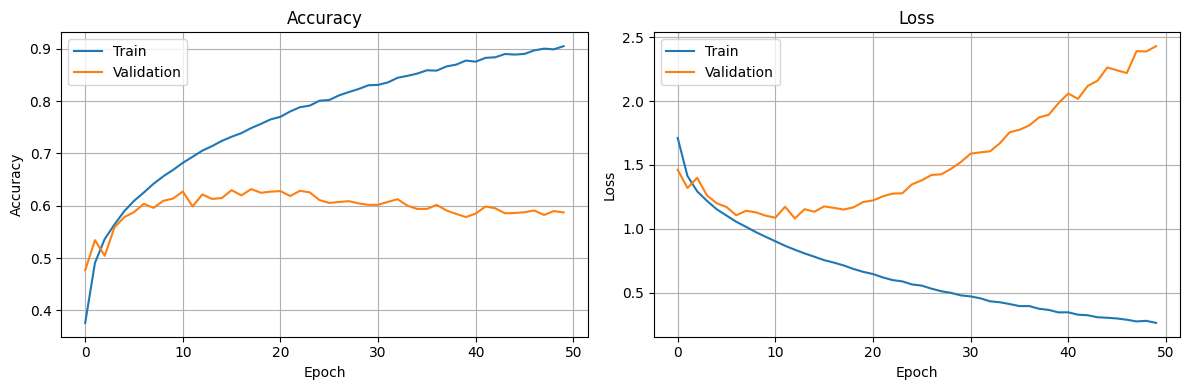

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


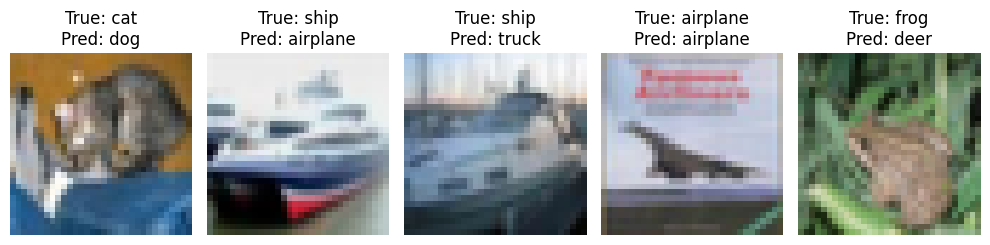

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------
# Load and preprocess CIFAR-10 dataset
# -------------------------------------------------------------------
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Convert labels to one-hot encoding (10 classes)
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test  = keras.utils.to_categorical(y_test, num_classes=10)

# Create a validation split (10% of training data)
val_split = 0.1
num_val_samples = int(x_train.shape[0] * val_split)
x_val = x_train[:num_val_samples]
y_val = y_train[:num_val_samples]
x_train = x_train[num_val_samples:]
y_train = y_train[num_val_samples:]

print(f"Training: {x_train.shape[0]}, Validation: {x_val.shape[0]}, Test: {x_test.shape[0]}")

# -------------------------------------------------------------------
# Build the model exactly as requested:
#   Conv2D (6 filters, 5x5, stride 1, valid) -> MaxPool(2x2)
#   -> Conv2D (16 filters, 5x5, valid) -> MaxPool(2x2)
#   -> Flatten -> Dense(120) -> Dense(84) -> Dense(10)
# -------------------------------------------------------------------
model = keras.Sequential(name="LeNet5_Style_CIFAR10")

# First convolutional layer: 6 filters, 5x5, stride 1, valid padding (no padding)
# Input: 32x32x3 -> Output: 28x28x6  (32-5+1=28)
model.add(layers.Conv2D(6, kernel_size=(5,5), strides=(1,1),
                        activation='relu', padding='valid',
                        input_shape=(32,32,3)))
# Max pooling: 2x2, reduces 28x28 -> 14x14
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Second convolutional layer: 16 filters, 5x5, valid padding
# Input: 14x14x6 -> Output: 10x10x16 (14-5+1=10)
model.add(layers.Conv2D(16, kernel_size=(5,5), strides=(1,1),
                        activation='relu', padding='valid'))
# Max pooling: 2x2, reduces 10x10 -> 5x5
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Now the feature map is exactly 5x5x16 (as requested)
model.add(layers.Flatten())

# Fully connected layers
model.add(layers.Dense(120, activation='relu'))   # 3rd trainable layer
model.add(layers.Dense(84, activation='relu'))    # 4th trainable layer
model.add(layers.Dense(10, activation='softmax')) # output layer

# Display the architecture
model.summary()

# -------------------------------------------------------------------
# Compile the model
# -------------------------------------------------------------------
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# -------------------------------------------------------------------
# Train the model
# -------------------------------------------------------------------
batch_size = 64
epochs = 50

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_val, y_val),
                    verbose=1)

# -------------------------------------------------------------------
# Evaluate on test set
# -------------------------------------------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# -------------------------------------------------------------------
# Plot training curves
# -------------------------------------------------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Show example predictions
# -------------------------------------------------------------------
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

num_examples = 5
predictions = model.predict(x_test[:num_examples])
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test[:num_examples], axis=1)

plt.figure(figsize=(10,4))
for i in range(num_examples):
    plt.subplot(1, num_examples, i+1)
    plt.imshow(x_test[i])
    plt.title(f"True: {class_names[true_classes[i]]}\nPred: {class_names[pred_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, AveragePooling2D, ZeroPadding2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# ==========================================
# 1. Data Preparation (Reshape for CNN)
# ==========================================
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

# ԿԱՐԵՎՈՐ: CNN-ի համար պետք է ավելացնել անցուղու (channel) չափսը -> (28, 28, 1)
x_train_full = np.expand_dims(x_train_full, -1) / 255.0
x_test = np.expand_dims(x_test, -1) / 255.0

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# ==========================================
# 2. CNN Model Architecture (LeNet-5 Based)
# ==========================================
model = Sequential([
    # Քանի որ մեր պատկերը 28x28 է, ավելացնում ենք padding, որ դառնա 32x32 (ինչպես նկարում է)
    ZeroPadding2D(padding=(2, 2), input_shape=(28, 28, 1)),

    # C1: Convolutional layer: 6 filters, 5x5 kernel, valid padding
    # Input: 32x32x1 -> Output: 28x28x6
    Conv2D(6, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid', kernel_regularizer=l2(1e-4)),

    # S2: Average pooling (2x2) -> Output: 14x14x6
    AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

    # C3: Convolutional layer: 16 filters, 5x5 kernel, valid padding
    # Input: 14x14x6 -> Output: 10x10x16
    Conv2D(16, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid', kernel_regularizer=l2(1e-4)),

    # S4: Average pooling (2x2) -> Output: 5x5x16
    AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Տափակեցնում ենք 3D ծավալը վեկտորի՝ 5x5x16 = 400 նեյրոն
    Flatten(),

    # C5/FC5: Fully Connected Layer: 120 neurons, tanh
    Dense(120, activation='tanh', kernel_regularizer=l2(1e-4)),
    Dropout(0.3), # Պահում ենք քո կոդի Dropout-ը՝ գերուսուցումից խուսափելու համար

    # F6: Fully Connected Layer: 84 neurons, tanh
    Dense(84, activation='tanh', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    # Output Layer: 10 classes, Softmax
    Dense(10, activation='softmax')
])

# ==========================================
# 3. Setup Optimizer and Loss
# ==========================================
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Մոդելի կառուցվածքի տեսապատկերում (ստուգելու համար չափսերը)
model.summary()

# ==========================================
# 4. Early Stopping Callback
# ==========================================
early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True,
                           verbose=1)

# ==========================================
# 5. The Training Loop
# ==========================================
print("\nStarting CNN training with Early Stopping...")
history = model.fit(x_train_full, y_train_full,
                    epochs=50,
                    batch_size=64,
                    validation_split=0.166,
                    callbacks=[early_stop])

# ==========================================
# 6. Evaluation & Classification Report
# ==========================================
print("\nEvaluating the best CNN model on unseen Test Data...")
predictions_probs = model.predict(x_test)
predicted_classes = np.argmax(predictions_probs, axis=1)

acc = accuracy_score(y_test, predicted_classes)
print(f"\nOverall Test Accuracy: {acc * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, predicted_classes, target_names=classes))